In [1]:
from backtest_engine import *
import numpy as np
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]

df = request(
    ticker="SPY",
    config=config,
)

Loading data from local cache: cache_SPY_20170101_20260620.parquet


In [2]:
# instantiate a portfolio backtest - behaviour is swapped via strategy=/execution=/cost_model= kwargs instead of subclassing
p = Portfolio(df)

print(p)
print(p.sharpe)

Portfolio(AUM: $100,000, Sharpe: 1.18, Period: [2017-01-26 - 2026-06-18])
1.1848185387527055


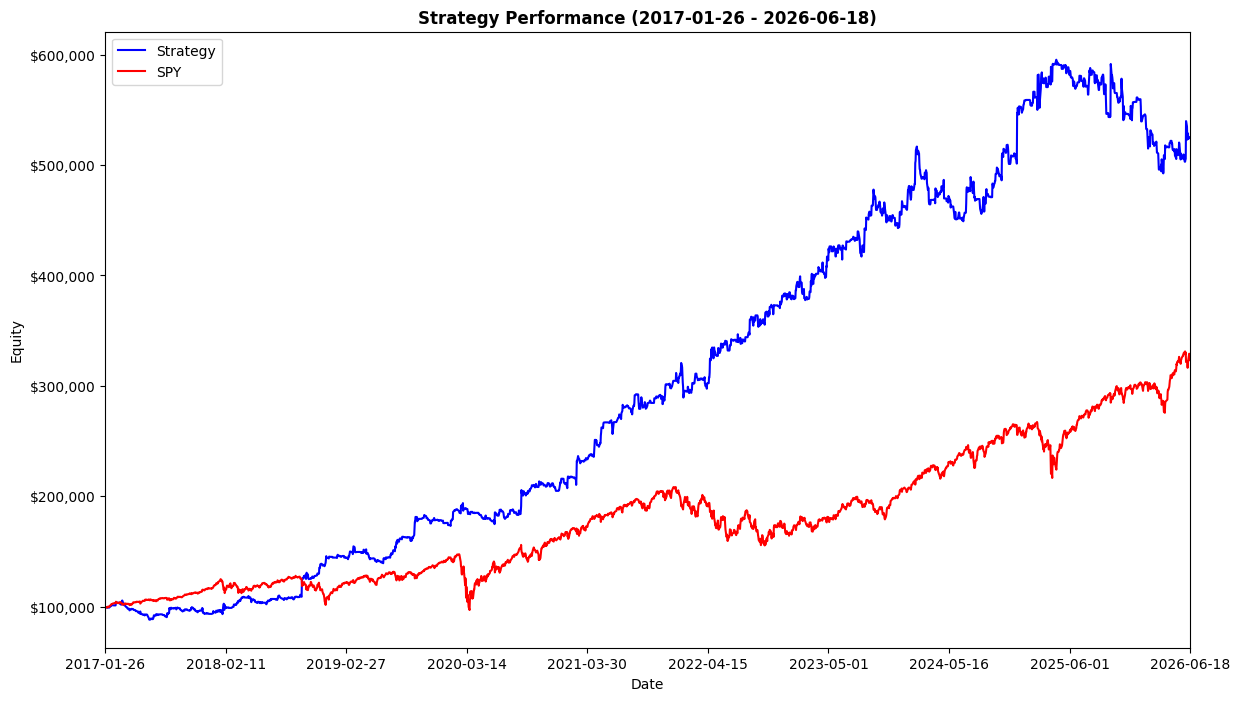

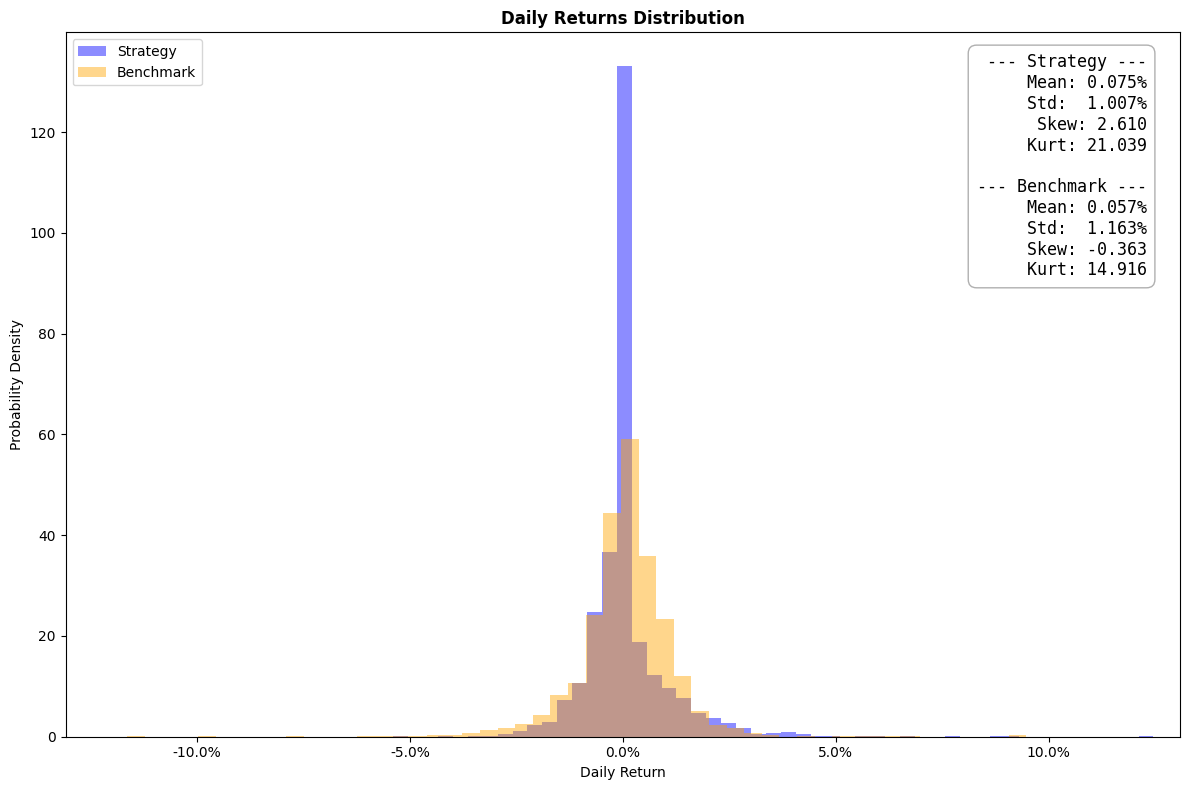

                             Strategy   Benchmark
Total Days                      2,362       2,362
                                                 
> Return Profile                                 
Cum. Return                   424.39%     230.32%
Ann. Return                    19.34%      13.60%
Avg. Daily Return               0.08%       0.06%
Ret. Skew                        2.61       -0.36
Ret. Kurtosis                   21.04       14.92
                                                 
> Trades                                         
Max Gain                       12.46%       9.47%
Max Loss                       -5.39%     -11.63%
Best Day                   2018-10-10  2020-03-24
Worst Day                  2018-02-06  2020-03-16
Daily Win Rate                 29.51%      55.63%
Win Rate                       40.70%           -
Average Trades / Day             1.06           -
Average Return / Trade          0.17%           -
Total Trades                    2,494           -


In [3]:
# backtest result over the entire data range provided
# returns a Tearsheet object when decompose param is false (default)
t = p.report()

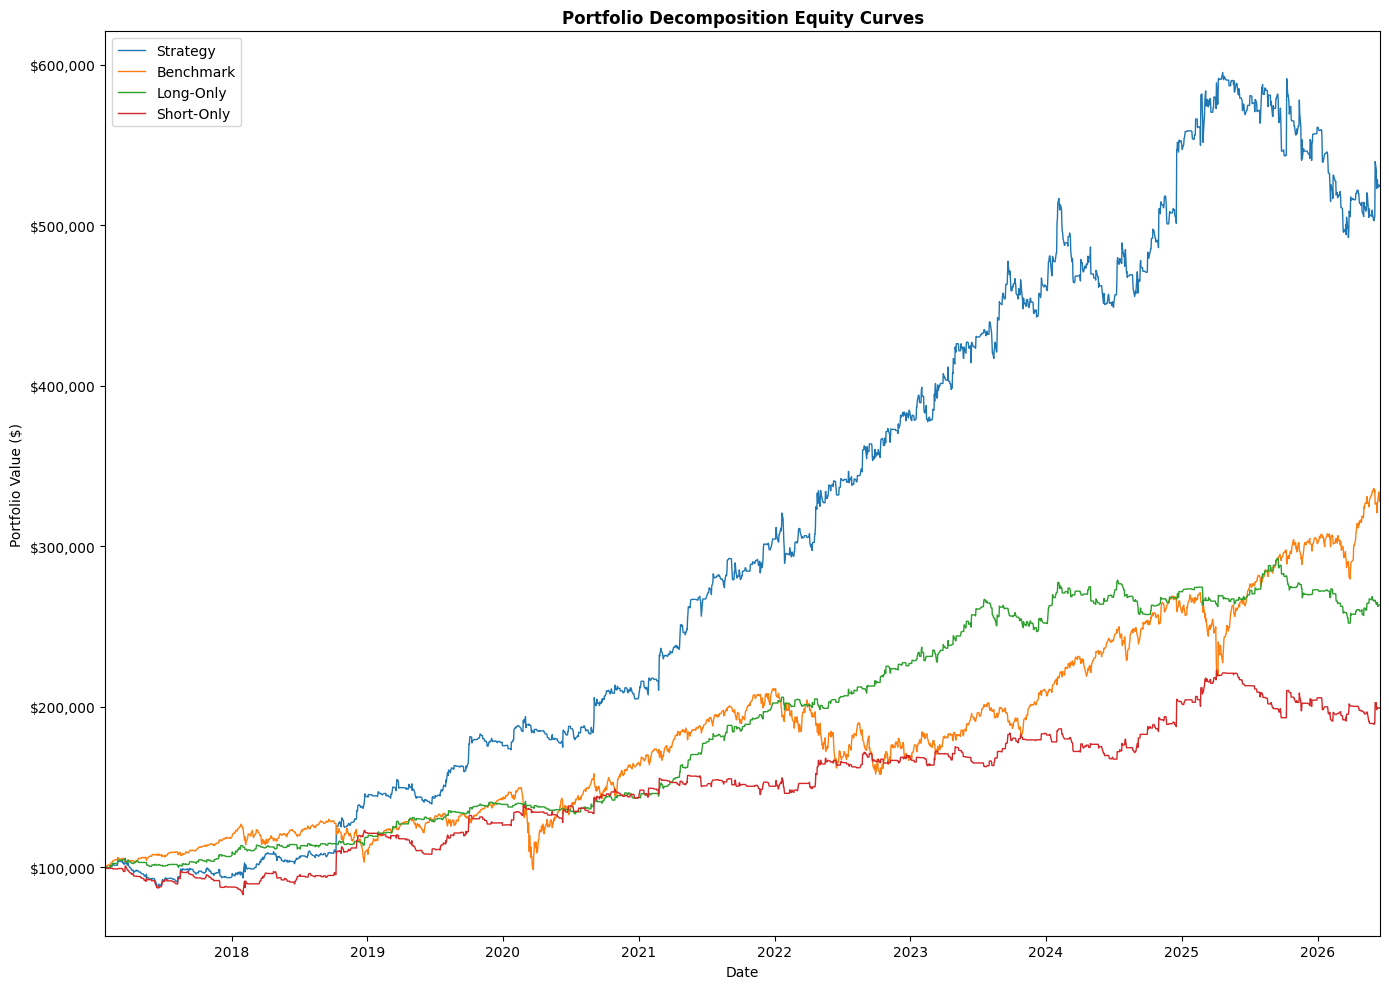

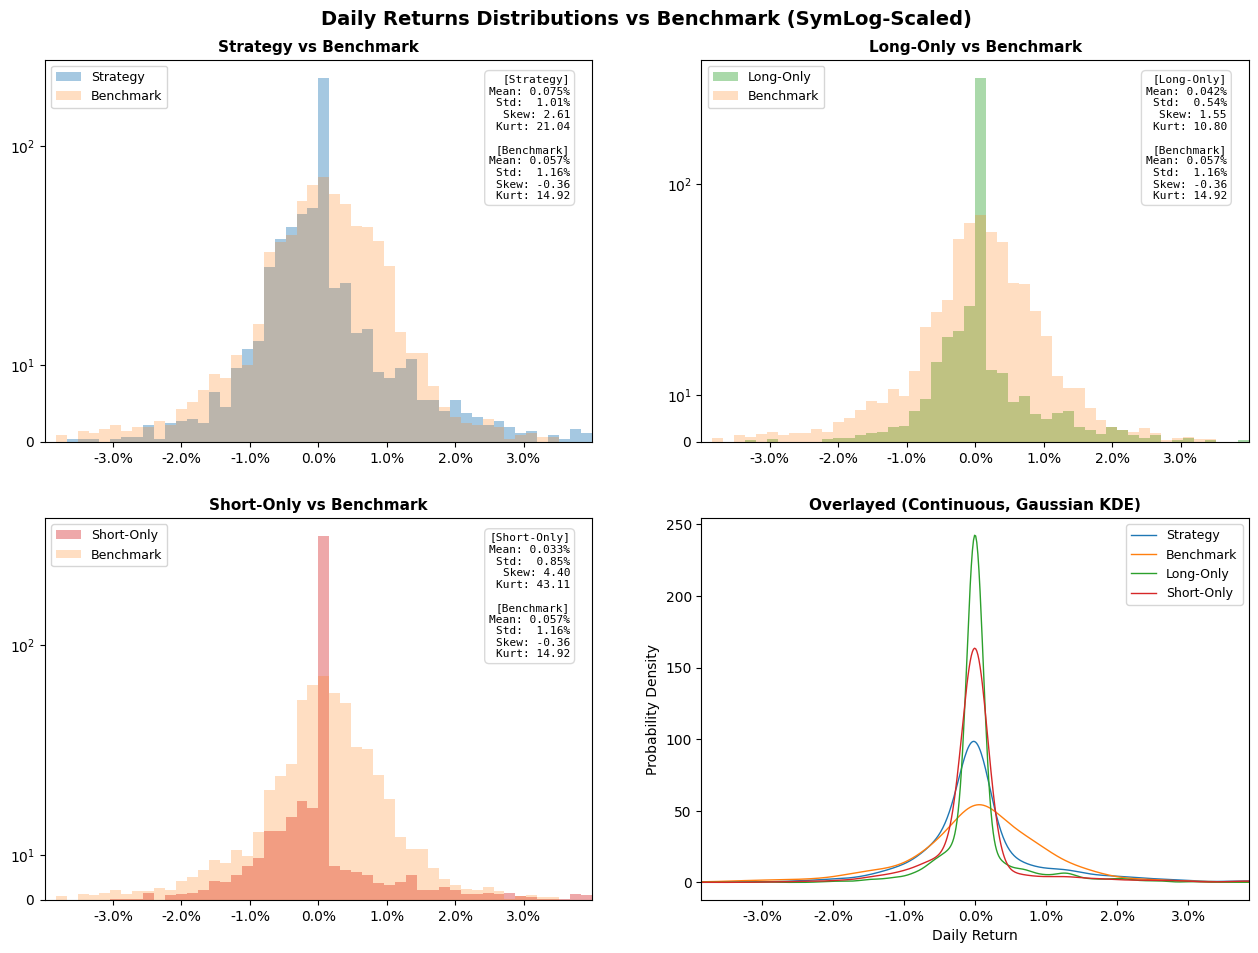

                             Strategy   Long-Only  Short-Only   Benchmark
Total Days                      2,362       2,362       2,362       2,362
                                                                         
> Return Profile                                                         
Cum. Return                   424.39%     163.39%      99.09%     230.32%
Ann. Return                    19.34%      10.89%       7.62%      13.60%
Avg. Daily Return               0.08%       0.04%       0.03%       0.06%
Ret. Skew                        2.61        1.55        4.40       -0.36
Ret. Kurtosis                   21.04       10.80       43.11       14.92
                                                                         
> Trades                                                                 
Max Gain                       12.46%       4.22%      12.46%       9.47%
Max Loss                       -5.39%      -3.22%      -4.28%     -11.63%
Best Day                   2018-10-10 

In [4]:
# backtest decomposed into long and short legs
# returns a PortfolioDecomposer object
d = p.report(decompose=True)

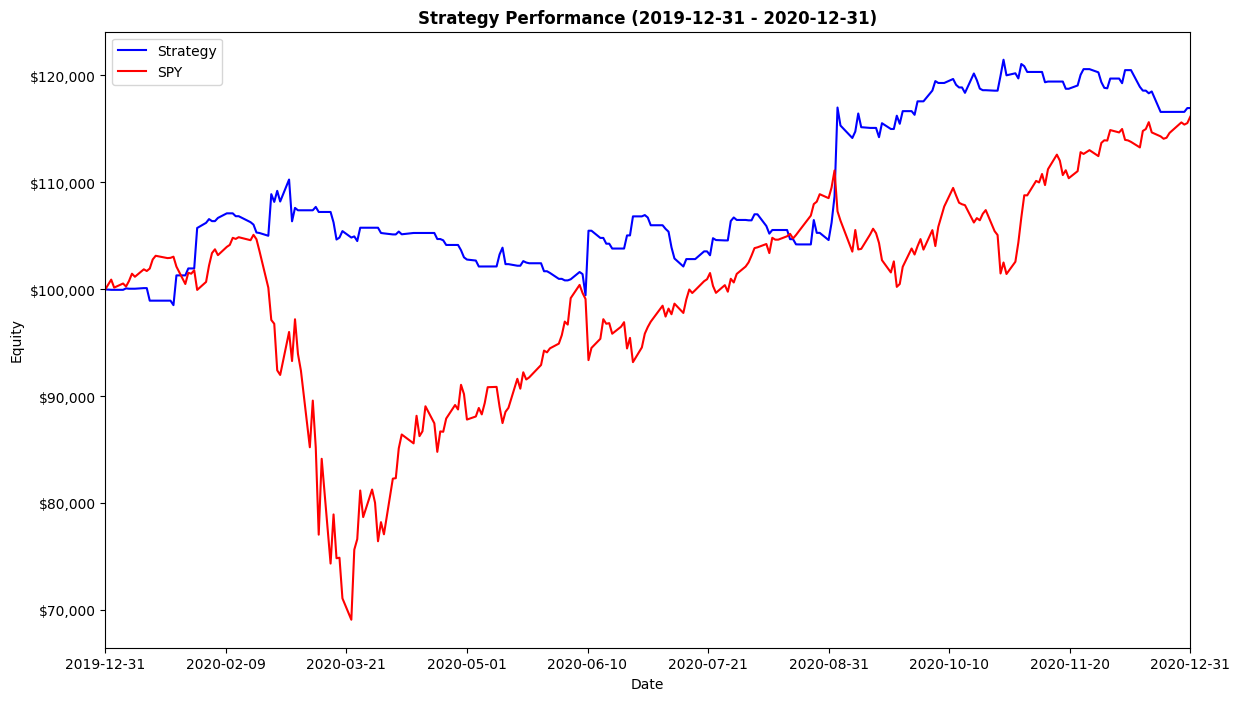

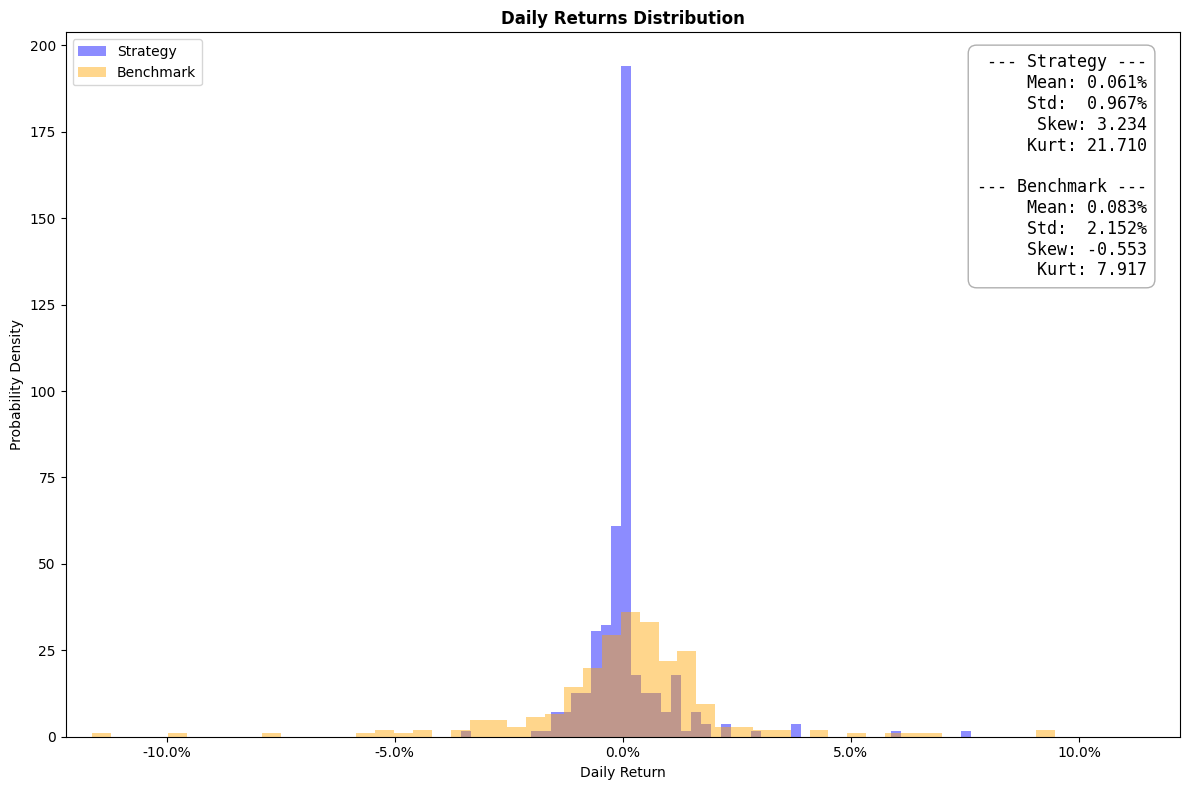

                             Strategy   Benchmark
Total Days                        254         254
                                                 
> Return Profile                                 
Cum. Return                    15.49%      16.43%
Ann. Return                    15.36%      16.29%
Avg. Daily Return               0.06%       0.08%
Ret. Skew                        3.23       -0.55
Ret. Kurtosis                   21.71        7.92
                                                 
> Trades                                         
Max Gain                        7.63%       9.47%
Max Loss                       -3.54%     -11.63%
Best Day                   2020-09-03  2020-03-24
Worst Day                  2020-03-03  2020-03-16
Daily Win Rate                 25.20%      57.87%
Win Rate                       37.14%           -
Average Trades / Day             0.96           -
Average Return / Trade          0.06%           -
Total Trades                      245           -


In [5]:
# backtest result over the provided date range
_ = p.report(start=date(2020, 1, 1), end=date(2021, 1, 1))

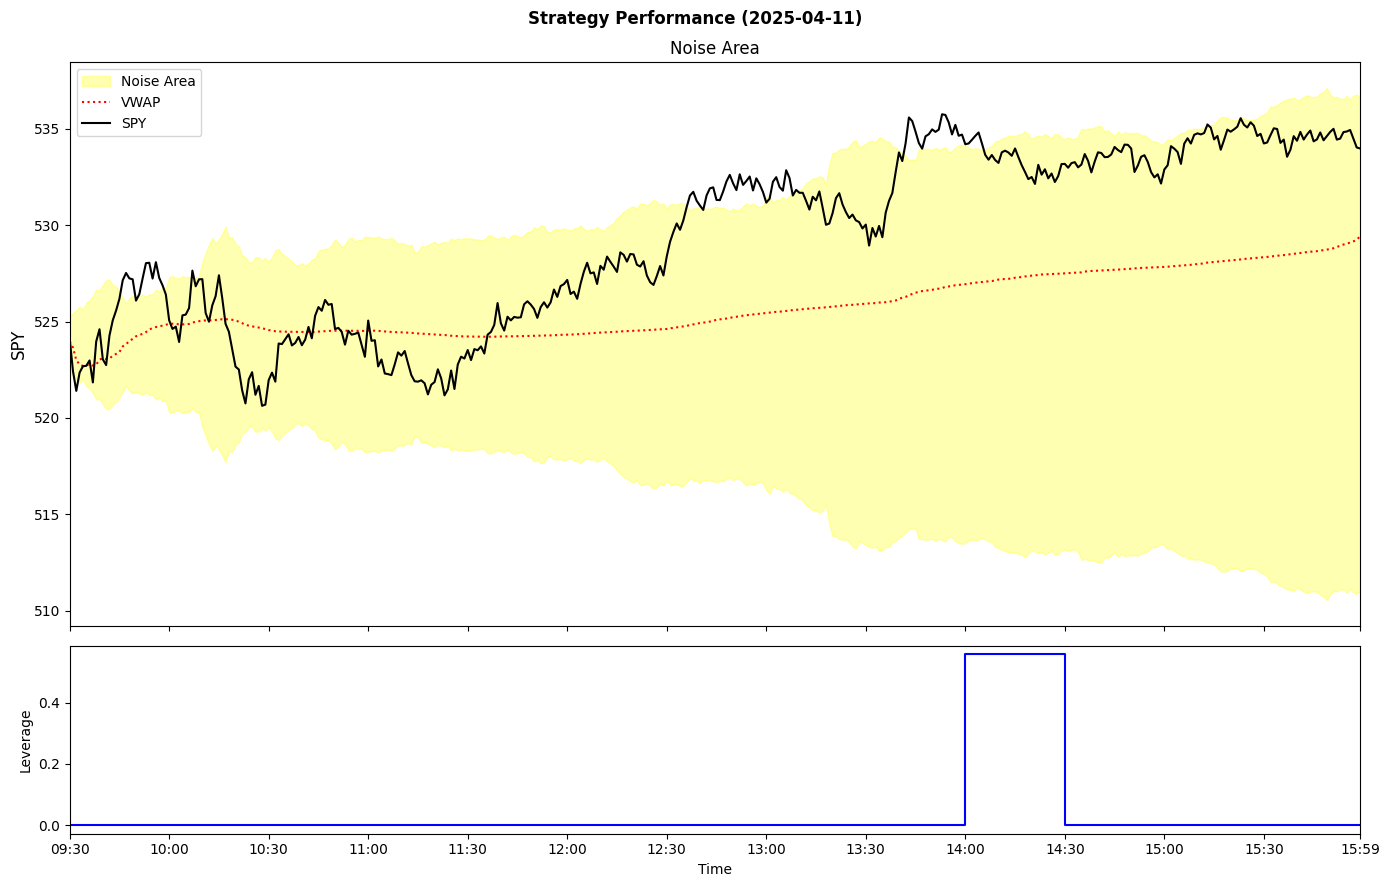

Strategy Return: -0.11%
Benchmark Return: 1.77%


In [6]:
# strategy actions over a specific day
# heavily tailored to visualise the SFI paper's strategy and will need to be rewritten for different strategies
# returns a DailySnapshot object
d = p.report(day=date(2025, 4, 12))

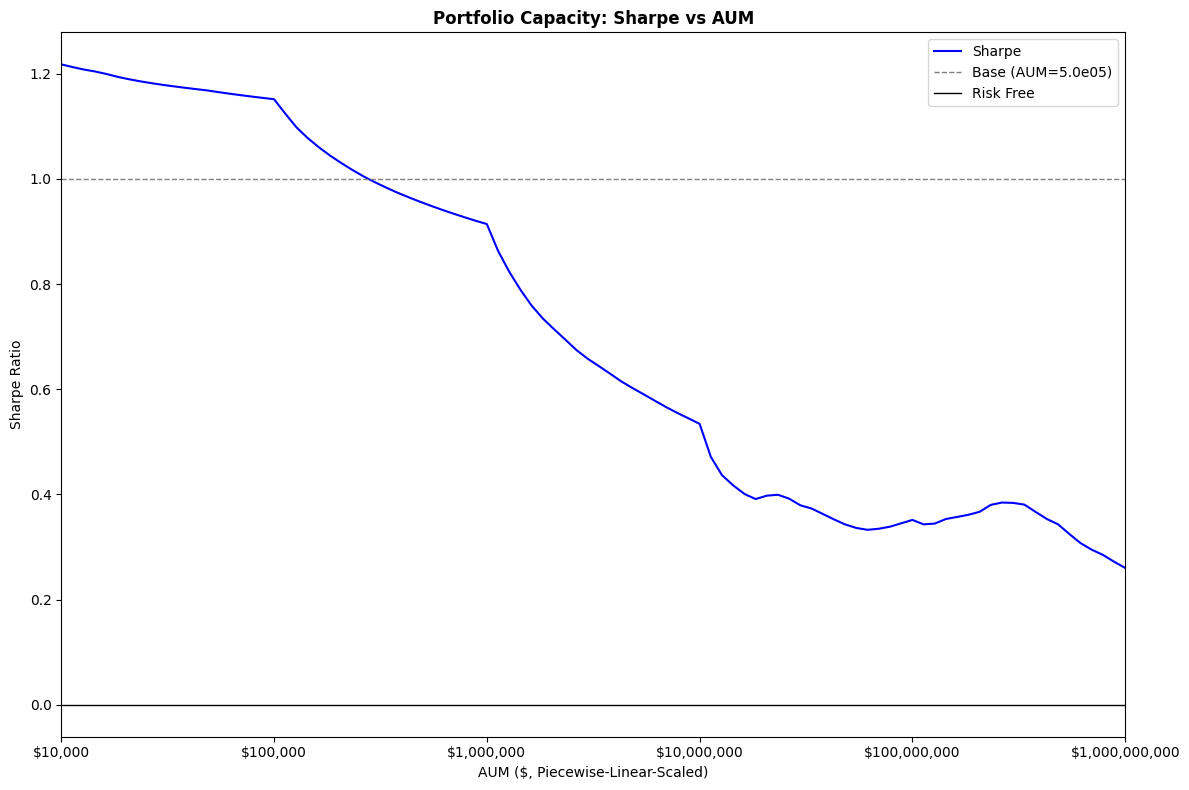

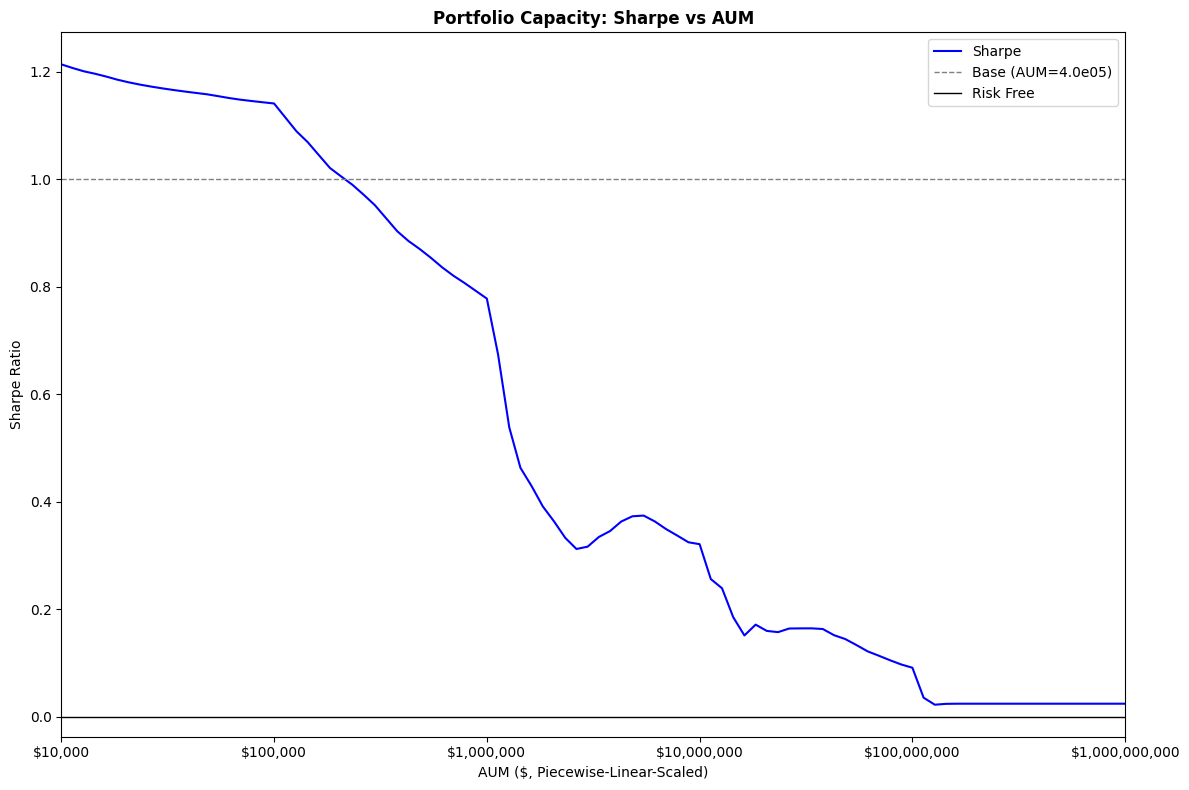

In [7]:
# classmethod, visualises capacity of a strategy
Portfolio.sharpe_curve(df=df, max_aum=1_000_000_000, resolution=19, cost_model=DynamicCostModel(), execution_model=CappedVolumeRolloverExecution())
Portfolio.sharpe_curve(df=df, max_aum=1_000_000_000, resolution=19, cost_model=DynamicCostModel(), execution_model=CappedVolumeExecution())

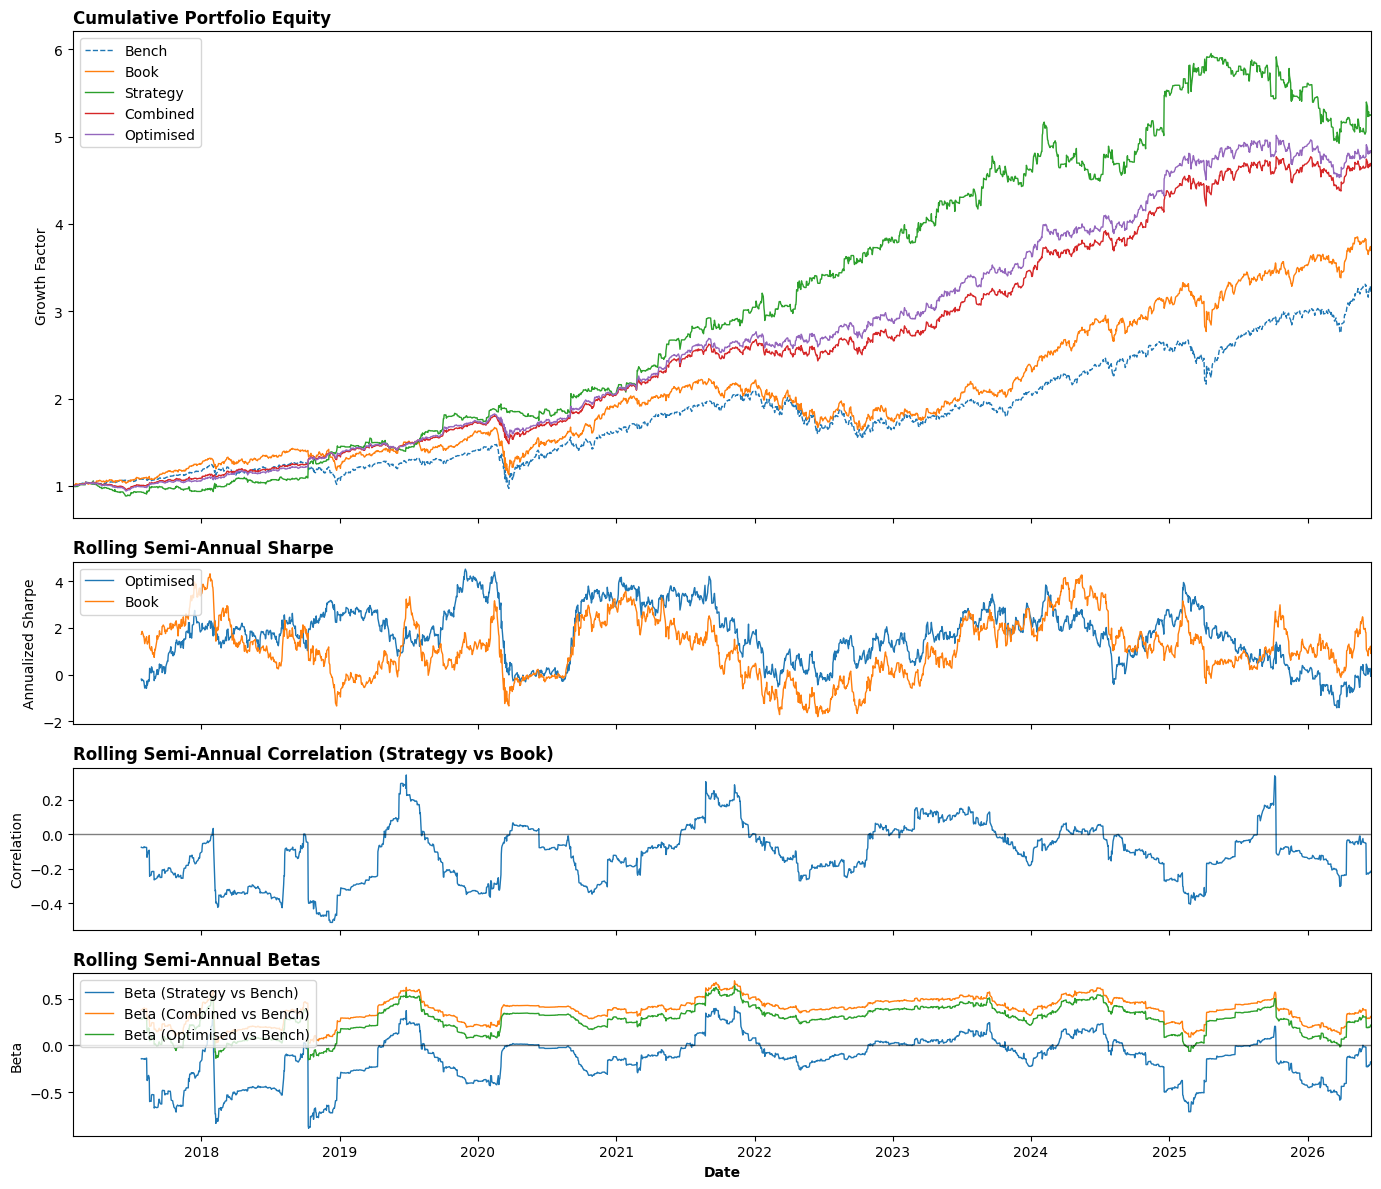

                                 Strategy        Book       Bench    Combined   Optimised
Total Days                          2,362       2,362       2,362       2,362       2,362
                                                                                         
> Return Profile                                                                         
Cum. Return                       424.39%     271.64%     225.34%     367.61%     382.49%
Ann. Return                        19.34%      15.03%      13.41%      17.89%      18.28%
Avg. Daily Return                   0.08%       0.06%       0.06%       0.07%       0.07%
Ret. Skew                            2.61       -0.38       -0.36        0.49        0.88
Ret. Kurtosis                       21.04        9.83       14.94        6.15        6.85
                                                                                         
> Trades                                                                                 
Max Gain  

In [8]:
ps = Portfolio(df, cost_model=DynamicCostModel(), long_permissions=False)

toy_book, _ = generate_toy_equity( # generate a toy book equity series
    portfolio=p,
    sharpe=1,
    volatility=0.18,
    beta=0.9,
    benchmark=df["close"],
)

sc = StrategyConnector(p, toy_book, df["close"]) # instantiate StrategyConnector tool to analyse strategy integration into current toy book

sc.report()

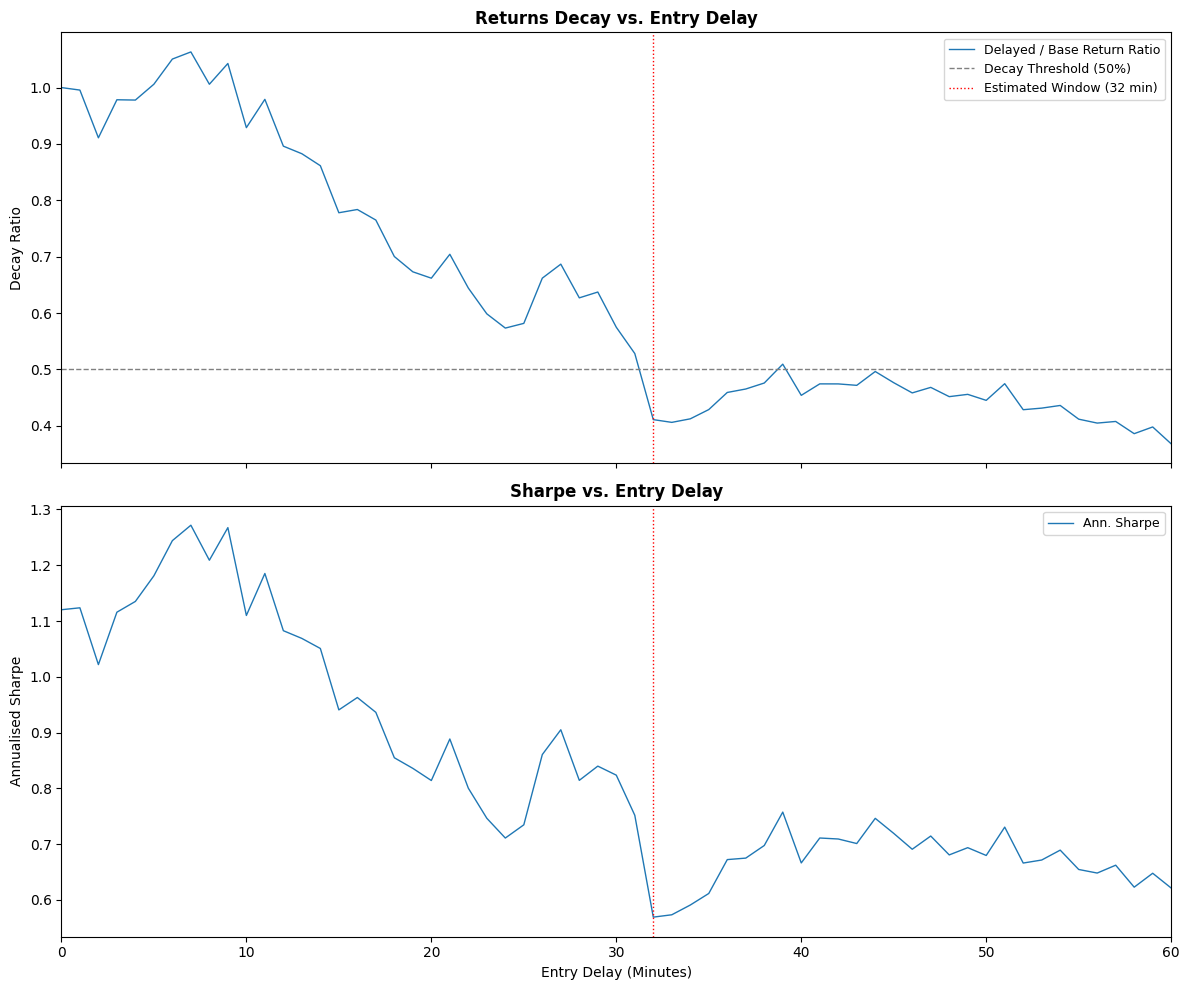

Alpha Decay Window: 32 min(s) (decays to 50% of immediate-entry return)
Peak Participation Rate: 10.0%
Avg. Volume / Min: 172,400 shares
Est. Capacity Bound: $226,117,013
Sharpe @ Base: 1.12
Sharpe @ Window <32 min>: 0.57


In [9]:
c = CapacityEstimator(Portfolio(df, cost_model=DynamicCostModel(), execution_model=CappedVolumeExecution()))
c.report()